In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving basic_info.csv to basic_info (1).csv
Saving ball_by_ball_ipl_data.csv to ball_by_ball_ipl_data (1).csv


In [4]:
basic = pd.read_csv("basic_info.csv")
ball = pd.read_csv("ball_by_ball_ipl_data.csv")

In [5]:
import os
os.listdir()

['.config',
 'basic_info.csv',
 'basic_info (1).csv',
 'ball_by_ball_ipl_data.csv',
 'ball_by_ball_ipl_data (1).csv',
 'sample_data']

In [6]:
basic.head()

,Unnamed: 0,id,city,gender,pom,toss_decision,winner,team_type,won_by
0,0,0,Hyderabad,male,Yuvraj Singh,field,Royal Challengers Bangalore,club,{'runs': 35}
1,1,1,Pune,male,SPD Smith,field,Rising Pune Supergiant,club,{'wickets': 7}
2,2,2,Rajkot,male,CA Lynn,field,Kolkata Knight Riders,club,{'wickets': 10}
3,3,3,Indore,male,GJ Maxwell,field,Kings XI Punjab,club,{'wickets': 6}
4,4,4,Bengaluru,male,KM Jadhav,bat,Royal Challengers Bangalore,club,{'runs': 15}


In [7]:
ball.head()

,Unnamed: 0,id,batter_name,bowler_name,non_striker_name,batsman_run,extra_run,total_run,batting_team,bowling_team
0,0,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
1,1,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
2,2,0,DA Warner,TS Mills,S Dhawan,4,0,4,Sunrisers Hyderabad,Royal Challengers Bangalore
3,3,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
4,4,0,DA Warner,TS Mills,S Dhawan,0,2,2,Sunrisers Hyderabad,Royal Challengers Bangalore


In [8]:
basic.shape


(1169, 9)

In [9]:
ball.shape

(278205, 10)

In [10]:
basic.columns

Index(['Unnamed: 0', 'id', 'city', 'gender', 'pom', 'toss_decision', 'winner',
       'team_type', 'won_by'],
      dtype='object')

In [11]:
ball.columns

Index(['Unnamed: 0', 'id', 'batter_name', 'bowler_name', 'non_striker_name',
       'batsman_run', 'extra_run', 'total_run', 'batting_team',
       'bowling_team'],
      dtype='object')

In [12]:
ball['current_score'] = ball.groupby('id')['total_run'].cumsum()

In [13]:
ball = ball.drop(columns=['Unnamed: 0'])

In [14]:
ball['ball_number'] = ball.groupby('id').cumcount() + 1

In [15]:
ball[['id','ball_number','total_run','current_score']].head(10)

,id,ball_number,total_run,current_score
0,0,1,0,0
1,0,2,0,0
2,0,3,4,4
3,0,4,0,4
4,0,5,2,6
5,0,6,0,6
6,0,7,1,7
7,0,8,1,8
8,0,9,4,12
9,0,10,1,13


In [16]:
batter_runs = ball.groupby('batter_name')['batsman_run'].sum().reset_index()

In [17]:
top_batters = batter_runs.sort_values(by='batsman_run', ascending=False).head(10)
top_batters

,batter_name,batsman_run
658,V Kohli,8671
500,RG Sharma,7048
535,S Dhawan,6769
151,DA Warner,6567
569,SK Raina,5536
389,MS Dhoni,5439
297,KL Rahul,5235
31,AB de Villiers,5181
51,AM Rahane,5032
128,CH Gayle,4997


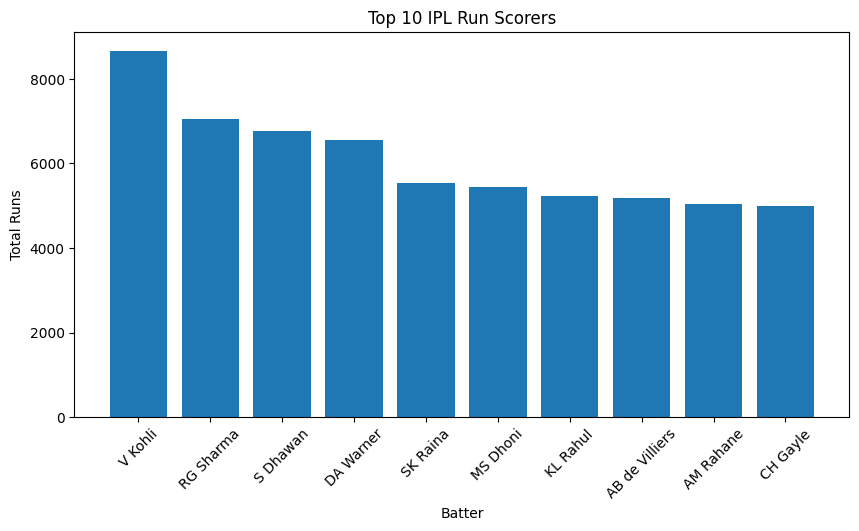

In [18]:
plt.figure(figsize=(10,5))
plt.bar(top_batters['batter_name'], top_batters['batsman_run'])
plt.xticks(rotation=45)
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.show()

In [19]:
ball['id'].nunique()

1169

In [20]:
ball['balls_left'] = 120 - ball['ball_number']

In [21]:
ball['current_run_rate'] = ball['current_score'] / (ball['ball_number'] / 6)

In [22]:
ball['runs_per_ball'] = ball['current_score'] / ball['ball_number']

In [23]:
data = ball.merge(basic, on='id')

In [24]:
data['result'] = (data['batting_team'] == data['winner']).astype(int)

In [ ]:
#1 = batting team wins
#0 = batting team loses

In [25]:
model_data = data[['current_score','balls_left','current_run_rate','runs_per_ball','result']]

In [26]:
model_data.head()

,current_score,balls_left,current_run_rate,runs_per_ball,result
0,0,119,0.0,0.000000,0
1,0,118,0.0,0.000000,0
2,4,117,8.0,1.333333,0
3,4,116,6.0,1.000000,0
4,6,115,7.2,1.200000,0


In [27]:
model_data.isnull().sum()

,0
current_score,0
balls_left,0
current_run_rate,0
runs_per_ball,0
result,0


In [28]:
model_data = model_data.dropna()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [30]:
X = model_data.drop('result', axis=1)
y = model_data['result']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [33]:
predictions = model.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test,predictions)
print(accuracy)

0.6403910785212343


In [35]:
model.predict_proba(X_test)

array([[0.66589511, 0.33410489],
       [0.43892065, 0.56107935],
       [0.47101779, 0.52898221],
       ...,
       [0.65516476, 0.34483524],
       [0.72600238, 0.27399762],
       [0.56832152, 0.43167848]])

In [36]:
X_test['win_probability'] = model.predict_proba(X_test)[:,1]
X_test.head()

,current_score,balls_left,current_run_rate,runs_per_ball,win_probability
108009,61,74,7.956522,1.326087,0.334105
86831,208,-37,7.949045,1.324841,0.561079
157425,184,-29,7.409396,1.234899,0.528982
220025,202,-2,9.934426,1.655738,0.522318
236172,6,104,2.250000,0.375000,0.419302


In [37]:
X_test = X_test[X_test['balls_left'] >= 0]

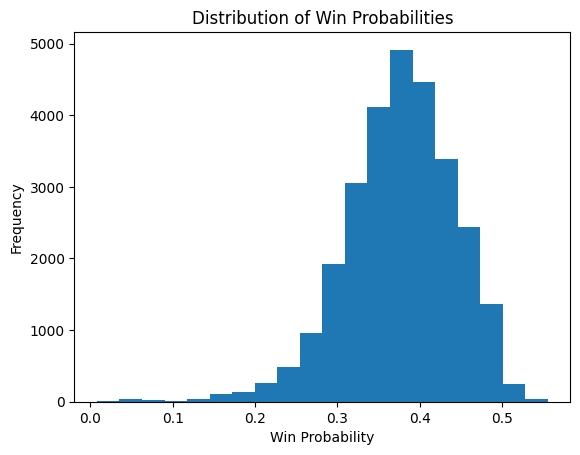

In [38]:
import matplotlib.pyplot as plt

plt.hist(X_test['win_probability'], bins=20)
plt.xlabel("Win Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Win Probabilities")
plt.show()

In [39]:
import numpy as np

situation = np.array([[120,30,9,1.5]])

model.predict_proba(situation)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.61132062, 0.38867938]])

In [41]:
X_test = X_test.sort_values('balls_left')

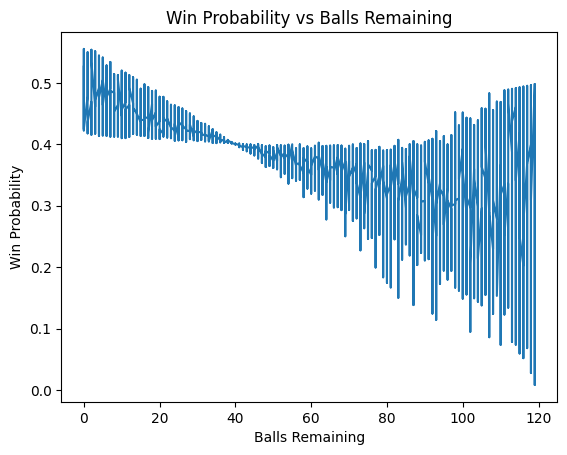

In [42]:
import matplotlib.pyplot as plt

plt.plot(X_test['balls_left'], X_test['win_probability'])
plt.xlabel("Balls Remaining")
plt.ylabel("Win Probability")
plt.title("Win Probability vs Balls Remaining")
plt.show()

In [43]:
score = float(input("Enter current score: "))
balls_left = float(input("Enter balls remaining: "))
run_rate = float(input("Enter current run rate: "))
runs_per_ball = score / (120 - balls_left)

Enter current score: 178
Enter balls remaining: 24
Enter current run rate: 11


In [44]:
import numpy as np

situation = np.array([[score, balls_left, run_rate, runs_per_ball]])

In [45]:
probability = model.predict_proba(situation)[0][1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [46]:
print("Win Probability:", round(probability*100,2), "%")

Win Probability: 45.79 %


In [47]:
data['win_probability'] = model.predict_proba(
    data[['current_score','balls_left','current_run_rate','runs_per_ball']]
)[:,1]

data[['id','ball_number','current_score','balls_left','win_probability']].head()

,id,ball_number,current_score,balls_left,win_probability
0,0,1,0,119,0.497866
1,0,2,0,118,0.496636
2,0,3,4,117,0.257693
3,0,4,4,116,0.311538
4,0,5,6,115,0.280961


In [49]:
match_id = data['id'].iloc[0]

match_data = data[data['id'] == match_id]

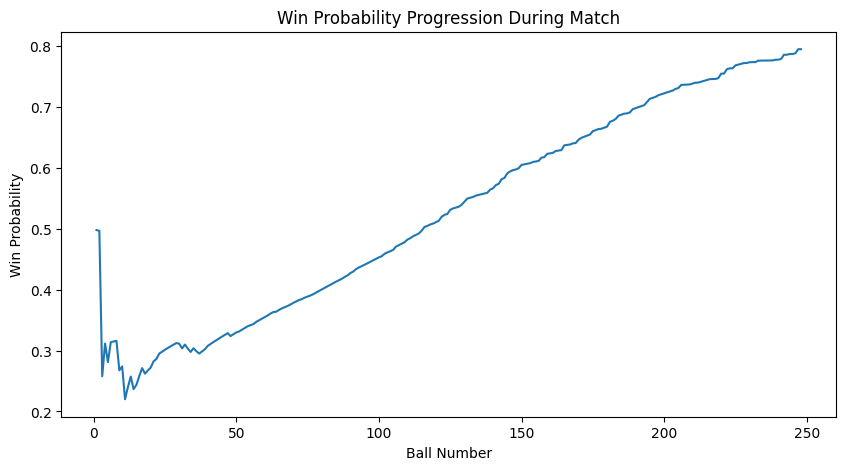

In [50]:
plt.figure(figsize=(10,5))

plt.plot(match_data['ball_number'], match_data['win_probability'])

plt.xlabel("Ball Number")
plt.ylabel("Win Probability")
plt.title("Win Probability Progression During Match")

plt.show()

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance

,Feature,Coefficient
0,current_score,0.010071
1,balls_left,0.004920
2,current_run_rate,-0.131339
3,runs_per_ball,-0.021890


In [52]:
def predict_win_probability(score, balls_left, run_rate):

    runs_per_ball = score / (120 - balls_left)

    situation = pd.DataFrame({
        'current_score':[score],
        'balls_left':[balls_left],
        'current_run_rate':[run_rate],
        'runs_per_ball':[runs_per_ball]
    })

    probability = model.predict_proba(situation)[0][1]

    return probability

In [53]:
def predict_win_probability(score, balls_left, run_rate):

    runs_per_ball = score / (120 - balls_left)

    situation = pd.DataFrame({
        'current_score':[score],
        'balls_left':[balls_left],
        'current_run_rate':[run_rate],
        'runs_per_ball':[runs_per_ball]
    })

    probability = model.predict_proba(situation)[0][1]

    return probability

In [54]:
score = float(input("Enter current score: "))
balls_left = float(input("Enter balls remaining: "))
run_rate = float(input("Enter current run rate: "))

prob = predict_win_probability(score, balls_left, run_rate)

print("Win Probability:", round(prob*100,2), "%")

Enter current score: 165
Enter balls remaining: 12
Enter current run rate: 9.1
Win Probability: 47.45 %
